# Simulate an LIF spiking model of an RGC

**author**: **laquitainesteeve@gmail.com**

**Week 2, Day 1**

**Learning outcomes:**

- Know how to simulate the subthreshold dynamic response of an RGC's membrane potential to inputs as an ordinary differential equation (ODE)
- Know how to use Python control structure, numpy arrays, functions for basic math operations
- Know how to use Python matplotlib to visualize the dynamic of RGC membrane potential.


---
# Setup

Setup your environment first.

In [1]:
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/master/nma.mplstyle")

NameError: name 'plt' is not defined

# 1: The LIF Model (subthreshold dynamics as an ODE)

A *membrane equation* and a *reset condition* define our *leaky-integrate-and-fire (LIF)* neuron:

\begin{align}
\tau_m\,\frac{d}{dt}\,V(t) &= E_{L} - V(t) + R\,I(t) &\text{if }\quad V(t) \leq V_{th} \\ \\
V(t) &= V_{reset} &\text{otherwise}
\end{align}

<br>

- where $V(t)$ is the membrane potential    
- $\tau_m$ is the membrane time constant     
- $E_{L}$ is the leak potential  
- $R$ is the membrane resistance
- $I(t)$ is the synaptic input current  
- $V_{th}$ is the firing threshold  
- $V_{reset}$ is the reset voltage.

We can also write $V_m$ for membrane potential, which is more convenient for plot labels.

The membrane equation describes the time evolution of membrane potential $V(t)$ in response to synaptic input and leaking of charge across the cell membrane.

The subthreshold membrane potential is described by an *ordinary differential equation (ODE)*.

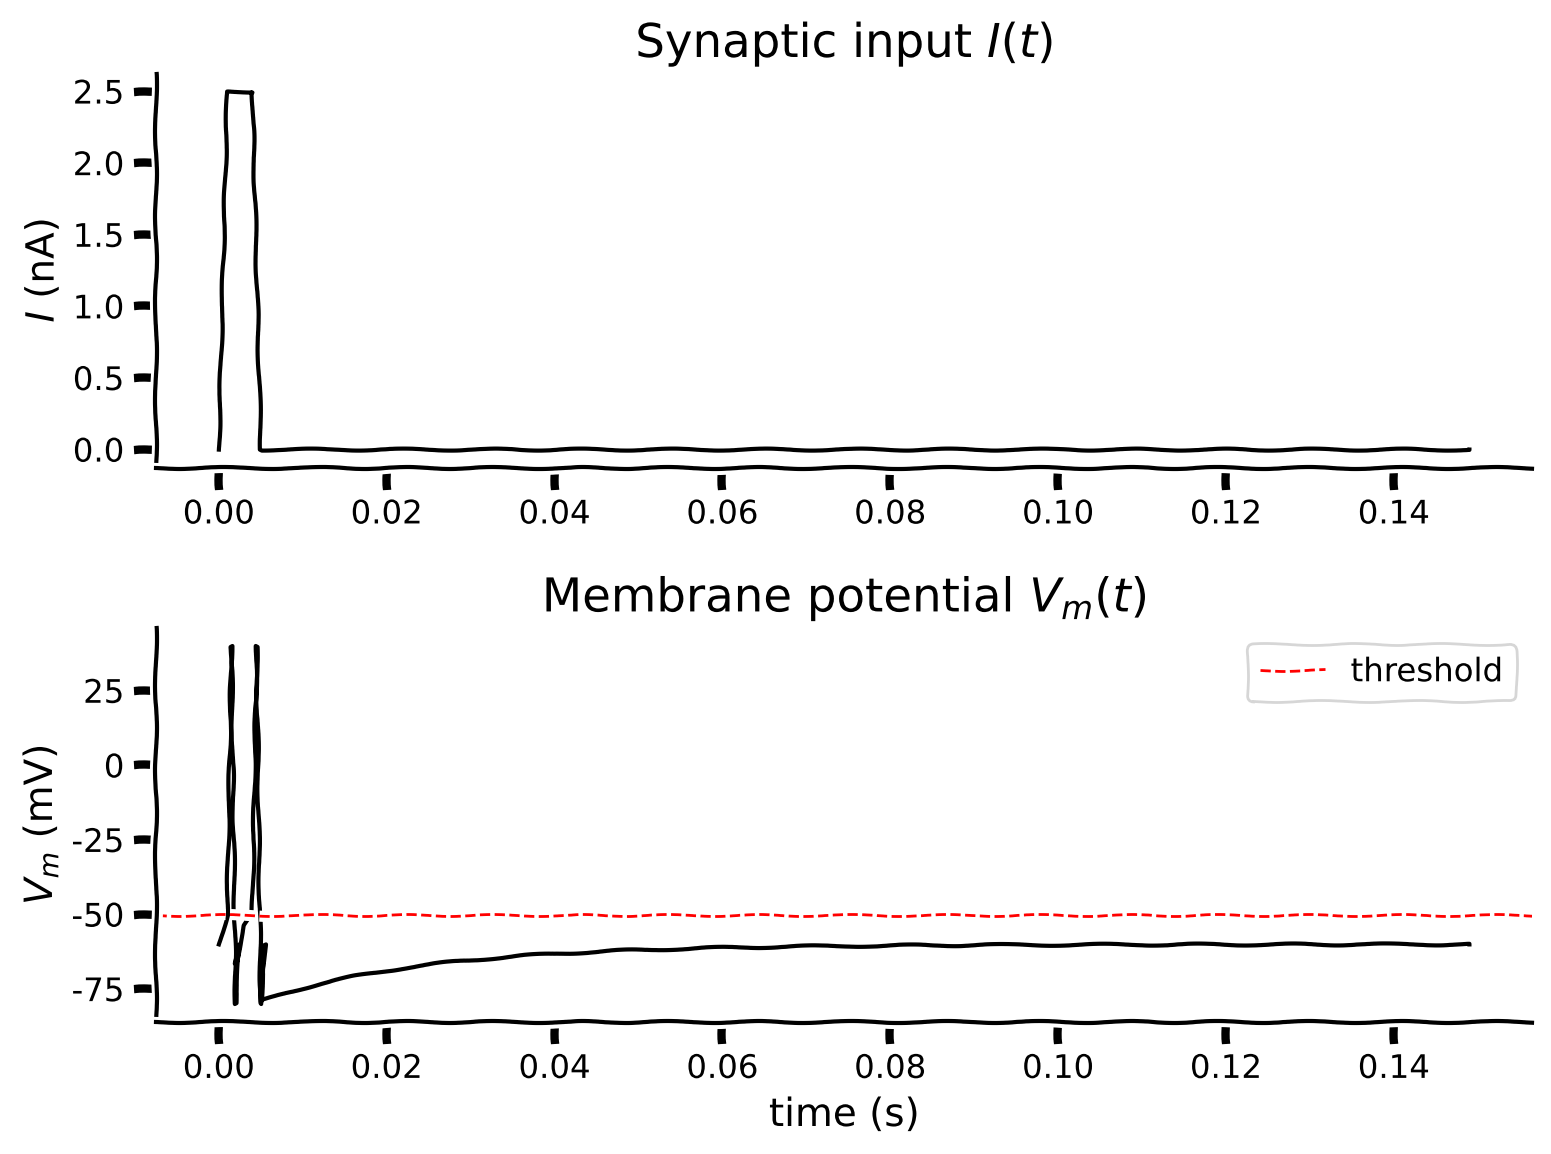

In [ ]:
# setup the parameter values
t_max = 150e-3   # second
dt = 1e-3

# Step impulse current parameters
t_start = 0.001   # impulse start (s)
t_end   = 0.004   # impulse end (s)
i_amp   = 2.5e-9  # amplitude (A)

# Spike parameters
v_threshold = -0.05   # -50 mV
v_reset     = -0.08   # -80 mV (hyperpolarisation after spike)
v_peak      =  0.04   # +40 mV (spike peak)

step_end = int(t_max / dt)
v = el

t_values = []
v_values = []
i_values = []

# loop over time bins
for step in range(step_end):

    # below threshold
    t = step * dt
    i = i_amp if t_start <= t <= t_end else 0.0
    i_values.append(i)

    v = v + dt / tau * (el - v + r * i)

    # above threshold
    if v >= v_threshold:
        t_values += [t, t + dt/2, t + dt, t + 3*dt/2]
        v_values += [v_threshold, v_peak, v_reset, el]
        v = v_reset
    else:
        t_values.append(t)
        v_values.append(v)

t_axis = np.arange(step_end) * dt

# plot
with plt.xkcd():
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=False)

    axes[0].plot(t_axis, np.array(i_values) * 1e9, 'k-', linewidth=1.5)
    axes[0].set_ylabel('$I$ (nA)')
    axes[0].set_title('Synaptic input $I(t)$')

    axes[1].plot(t_values, np.array(v_values) * 1e3, 'k-', linewidth=1.5)
    axes[1].axhline(v_threshold * 1e3, color='red', linestyle='--', linewidth=1, label='threshold')
    axes[1].set_xlabel('time (s)')
    axes[1].set_ylabel('$V_m$ (mV)')
    axes[1].set_title('Membrane potential $V_m(t)$')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

We start by defining and initializing the main simulation variables for our LIF neuron.

In [ ]:
# setup the parameter values
t_max = 150e-3   # second
dt = 1e-3        # second
tau = 20e-3      # second
el = -60e-3      # millivolt
vr = -70e-3      # millivolt
vth = -50e-3     # millivolt
r = 100e6        # ohm
i_mean = 95e-12  # ampere


# print them
print(t_max, dt, tau, el, vr, vth, r, i_mean)

0.15 0.001 0.02 -0.06 -0.07 -0.05 100000000.0 2.5e-10


## 1.2: Simulate input current $I(t)$



We simulate the synaptic input $I(t)$ that goes into our model neuron with a sinusoidal model:

\begin{equation}
I(t)=I_{mean}\left(1+\sin\left(\frac{2 \pi}{0.01}\,t\right)\right)
\end{equation}

- where $I_{mean}$: mean current input
- $t$: time.

In the next cell, we will compute the values of synaptic input $I(t)$ between $t=0$ and $t=0.009$ with step $\Delta t=0.001$.

<br>

**PYTHON BASICS: "FOR LOOPS"**:

- For loops allow us to run the same code block multiple times.

- In this case, we loop over steps so the variable *step* equals something new each time. We use the following syntax:

  ```python
  for step in range(10):
  ```

  This means that `step` will take each integer value between 0 and 9.

- The following three formulations are all equivalent and loop for three steps:

  ```
  for step in [0, 1, 2]:
    print(step)

  for step in range(3):
    print(step)

  for step in range(start=0, end=3, stepsize=1):
    print(step)
  ```


- The `range` python function returns a sequence of numbers, starting from 0 (by default), and increments by 1 (by default), and stops before a specified number.

  ```python
  range(start, stop, step)
  ```

Parameters:

- *start*: Optional. An integer number specifying at which position to start. Default is 0
- *stop*: Required. An integer number specifying at which position to stop (not included).
- *step*: Optional. An integer number specifying the incrementation. Default is 1


**PYTHON BASICS: "NUMPY"**:

- You can use `numpy.pi` as the value of $\pi$ and `numpy.sin(x)` to get the sine of x.

<br>


In [ ]:
# Loop for 10 steps, variable 'step' takes values from 0 to 9
for step in range(10):

  # Compute value of t
  t = step * dt

  # Compute value of i at this time step
  i = i_mean * (1 + np.sin((t * 2 * np.pi) / 0.01))

  # Print value of i
  print(i)

2.5e-10
3.969463130731183e-10
4.877641290737885e-10
4.877641290737885e-10
3.9694631307311837e-10
2.5000000000000007e-10
1.0305368692688176e-10
1.2235870926211617e-11
1.223587092621159e-11
1.0305368692688186e-10


---
# 2: Simulate RGC's membrane potential $V(t)$




## 2.2: Discrete time integration


- We will simulate the evolution of the membrane equation in discrete time steps, with a sufficiently small $\Delta t$.

- We start by writing the time derivative $d/dt\,V(t)$ in the membrane equation without taking the limit $\Delta t \to 0$:

\begin{equation}
\tau_m\,\frac{V\left(t+\Delta t\right)-V\left(t\right)}{\Delta t} = E_{L} - V(t) + R\,I(t) \qquad\qquad (1)
\end{equation}

- The membrane potential $V\left(t+\Delta t\right)$ can be expressed in terms of its previous value $V(t)$ by simple algebraic manipulation. For *small enough* values of $\Delta t$, this provides a good approximation of the continuous-time integration.

- The ODE describes the evolution of $\frac{d}{dt}\,V(t)$, the derivative of $V(t)$, but not of $V(t)$.

- For the evolution of $V(t)$ we need to integrate the ODE, and in this tutorial, we will do a discrete-time integration using the Euler method. See [Numerical methods for ordinary differential equations](https://en.wikipedia.org/wiki/Numerical_methods_for_ordinary_differential_equations) for additional details.

### 2.2.1: Simulating membrane potential

- Compute the values of $V(t)$ between $t=0$ and $t=0.01$ with step $\Delta t=0.001$ and $V(0)=E_L$.


- From Eq. (1), we isolate $V\left( t+\Delta t \right)$ on the left side, and express it as function of $V(t)$ and the other terms:

\begin{equation}
V(t + \Delta t) =  V(t) + \frac{\Delta t}{\tau_m}\left( E_L -V(t) + R I(t) \right)
\end{equation}

In [ ]:
# Initialize step_end and v0
step_end = 10
v = el

# Loop for step_end steps
for step in range(step_end):
  # Compute value of t
  t = step * dt

  # Compute value of i at this time step
  i = i_mean * (1 + np.sin((t * 2 * np.pi) / 0.01))

  # Compute v
  v = v + dt/tau * (el - v + r*i)

  # Print value of t and v
  print(f"{t:.3f} {v:.4e}")

0.000 -5.8750e-02
0.001 -5.6828e-02
0.002 -5.4548e-02
0.003 -5.2381e-02
0.004 -5.0778e-02
0.005 -4.9989e-02
0.006 -4.9974e-02
0.007 -5.0414e-02
0.008 -5.0832e-02
0.009 -5.0775e-02


---
# 3: Plotting current and membrane potential

## 3.1: Plot current $I(t)$

Here, we will plot the values of $I(t)$ between $t=0$ and $t=0.024$.

You will first need to set the title and axis labels of the plot. Label these descriptively!  You will then need to fill out the code to actually create the plot.


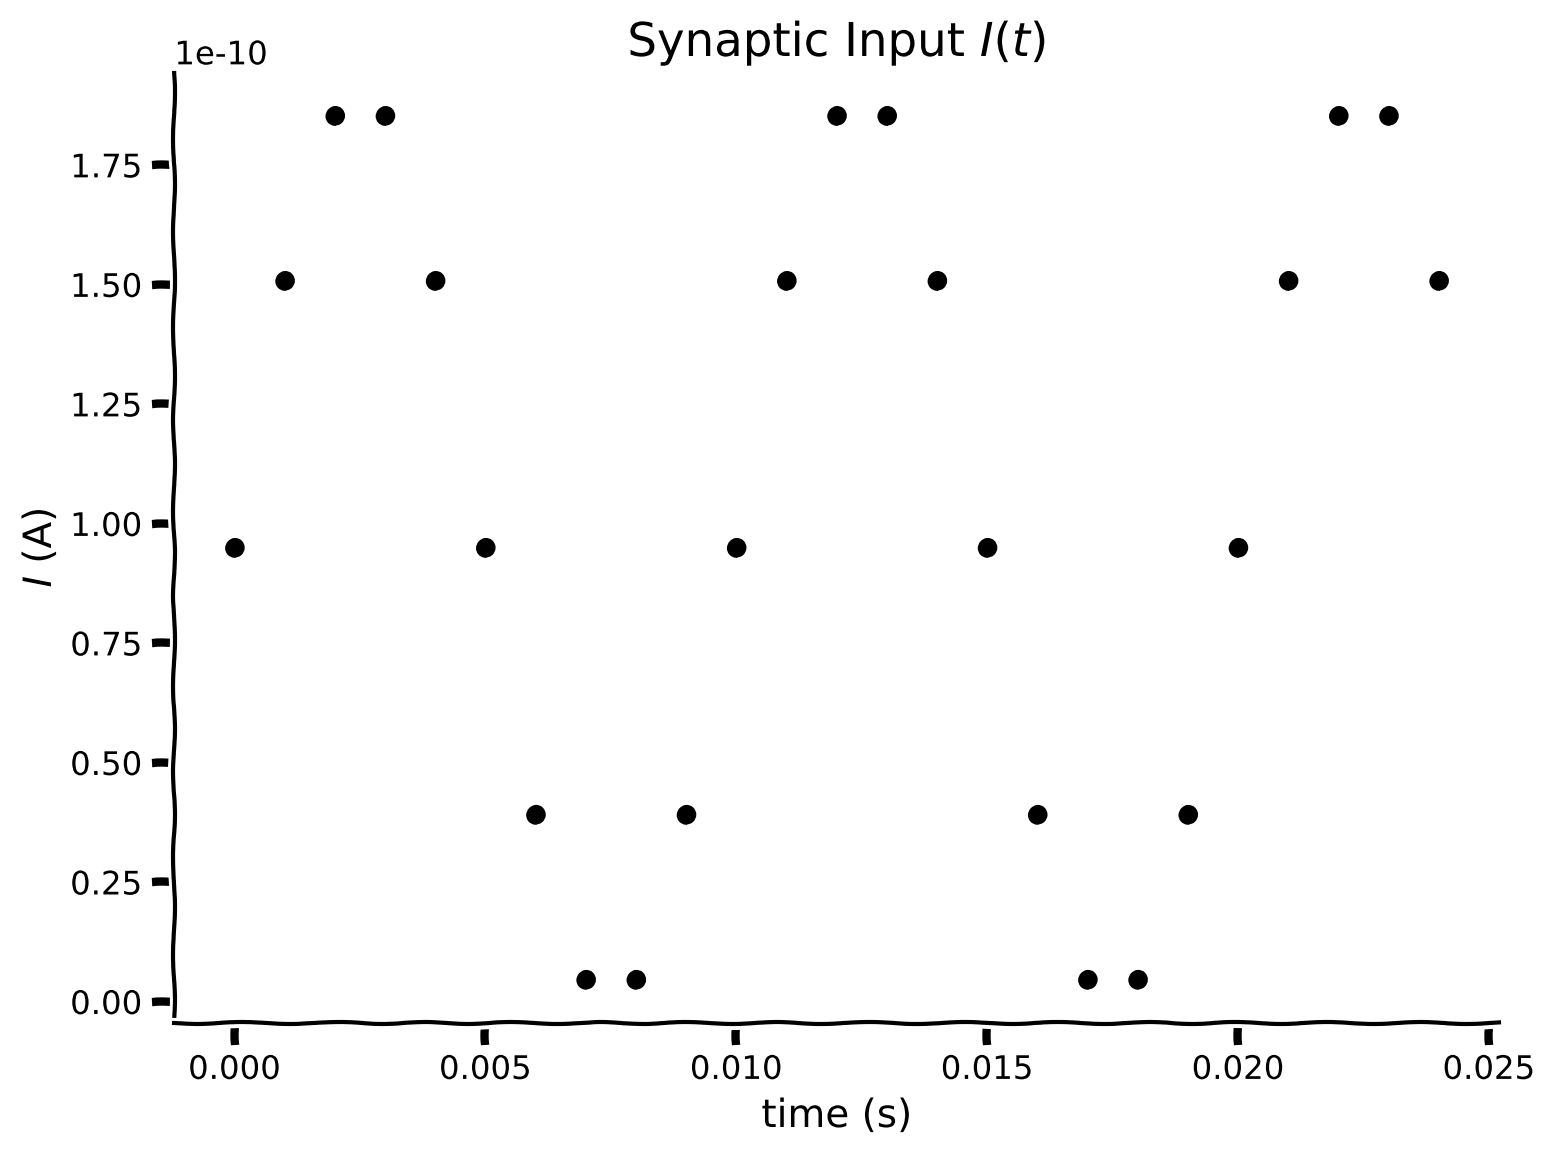

In [ ]:
# Initialize step_end
step_end = 25

with plt.xkcd():
  # Initialize the figure
  plt.figure()
  plt.title('Synaptic Input $I(t)$')
  plt.xlabel('time (s)')
  plt.ylabel('$I$ (A)')

  # Loop for step_end steps
  for step in range(step_end):

    # Compute value of t
    t = step * dt

    # Compute value of i at this time step
    i = i_mean * (1 + np.sin((t * 2 * np.pi) / 0.01))

    # Plot i (use 'ko' to get small black dots (short for color='k' and marker = 'o'))
    plt.plot(t, i, 'ko')

  # Display the plot
  plt.show()

## 3.2: Plot membrane potential $V(t)$

- Plot the values of $V(t)$ between $t=0$ and $t=t_{max}$.

- We can compute the number of steps required to get to $t=t_{max}$ given $\Delta t$ as `int(t_max/dt)` where `int` gets the nearest integer.


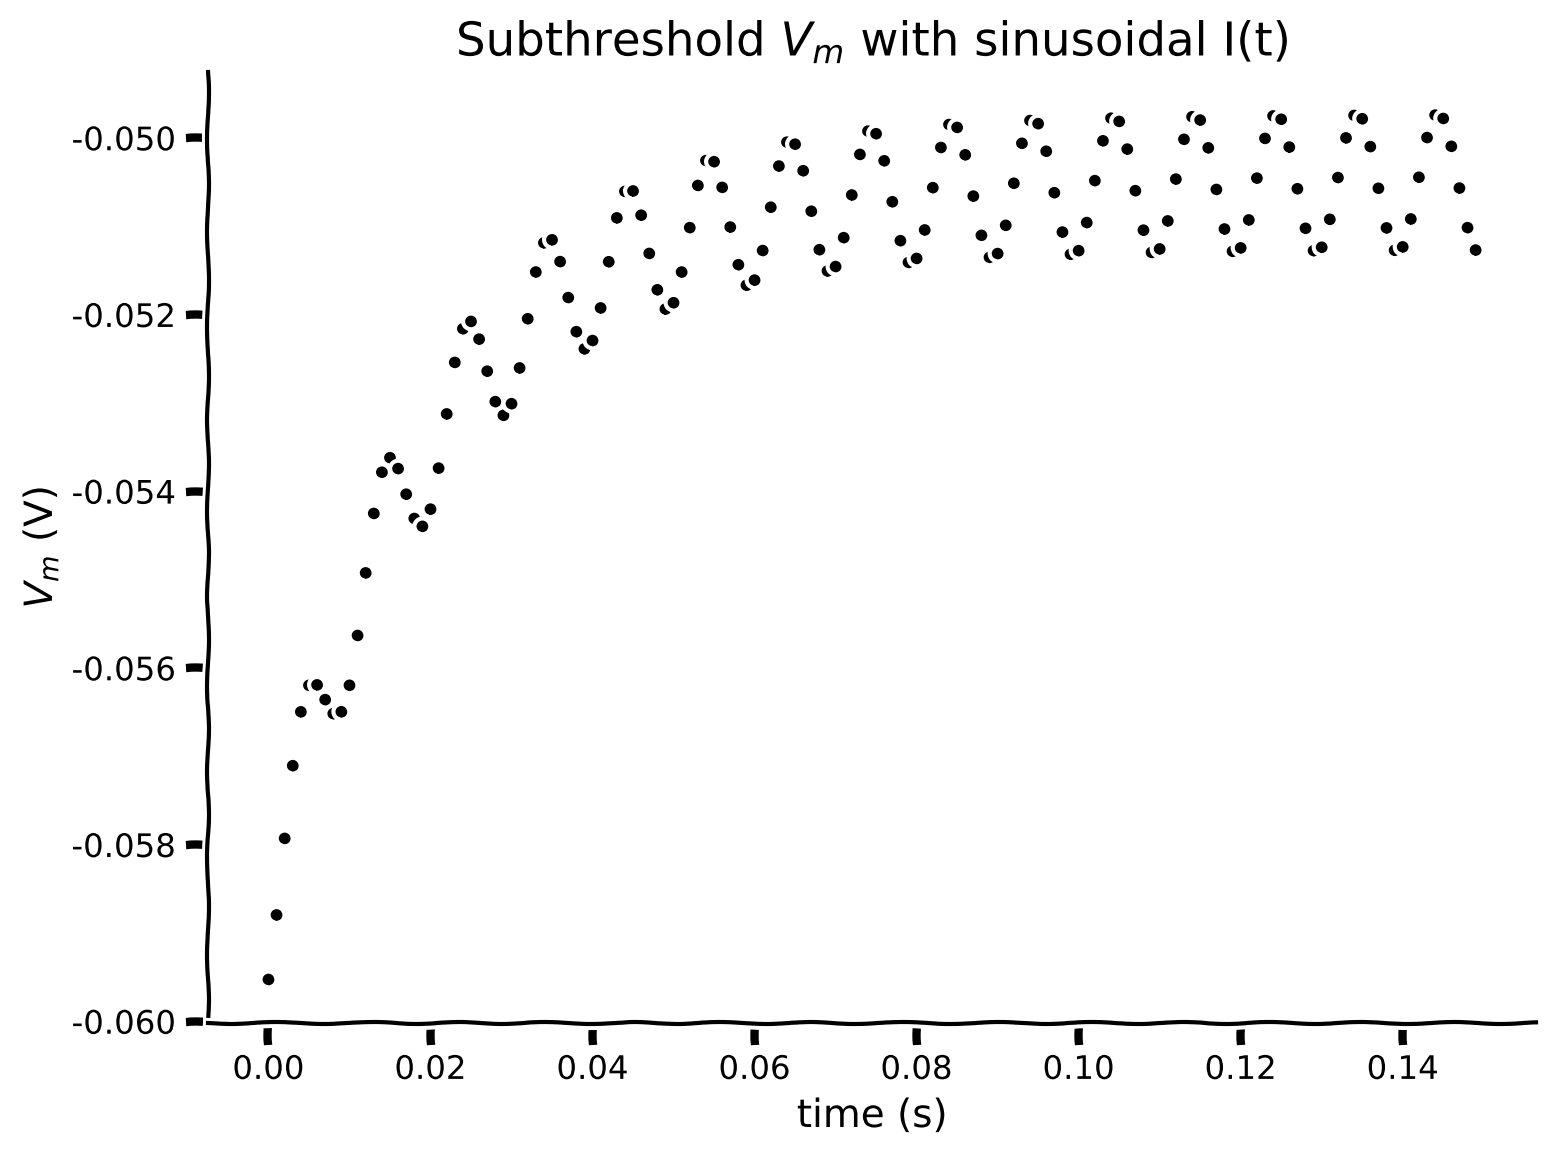

In [ ]:
# Initialize step_end
step_end = int(t_max / dt)

# Initialize v0
v = el

with plt.xkcd():

  # Initialize the figure
  plt.figure()
  plt.title('Subthreshold $V_m$ with sinusoidal I(t)')
  plt.xlabel('time (s)')
  plt.ylabel('$V_m$ (V)');

  # Loop for step_end steps
  for step in range(step_end):

    # Compute value of t
    t = step * dt

    # Compute value of i at this time step
    i = i_mean * (1 + np.sin((t * 2 * np.pi) / 0.01))

    # Compute v
    v = v + dt/tau * (el - v + r*i)

    # Plot v (using 'k.' to get even smaller markers)
    plt.plot(t, v, 'k.')

  # Display plot
  plt.show()

---
# 4: Random synaptic input



From the perspective of neurons, synaptic input is random (or stochastic). We'll improve the synaptic input model by introducing random input current with statistical properties similar to the previous exercise:

\begin{equation}
I(t) = I_{mean}\left(1+0.1\sqrt{\frac{t_{max}}{\Delta t}}\,\xi(t)\right)\qquad\text{with }\xi(t)\sim \mathcal{U}(-1,1)
\end{equation}

where $\mathcal{U}(-1,1)$ is the [uniform distribution](https://en.wikipedia.org/wiki/Uniform_distribution_(continuous)) with support $x\in[-1,1]$.

We can approximate randomness in code using a pseudo random number generator. The function `np.random.seed()` initializes the RNG. If we initialize this with a number (e.x. `np.random.seed(2)`), we will get the same random number draws each time we run the code. Basically, we are making the random number generation replicable. We do this here so you can get a figure that exactly matches the solution. The function `np.random.random()` generates samples from the uniform distribution between `0` and `1`.

## 4.1: Adding randomness

Plot the values of $V(t)$ between $t=0$ and $t=t_{max}-\Delta t$ with random input $I(t)$.


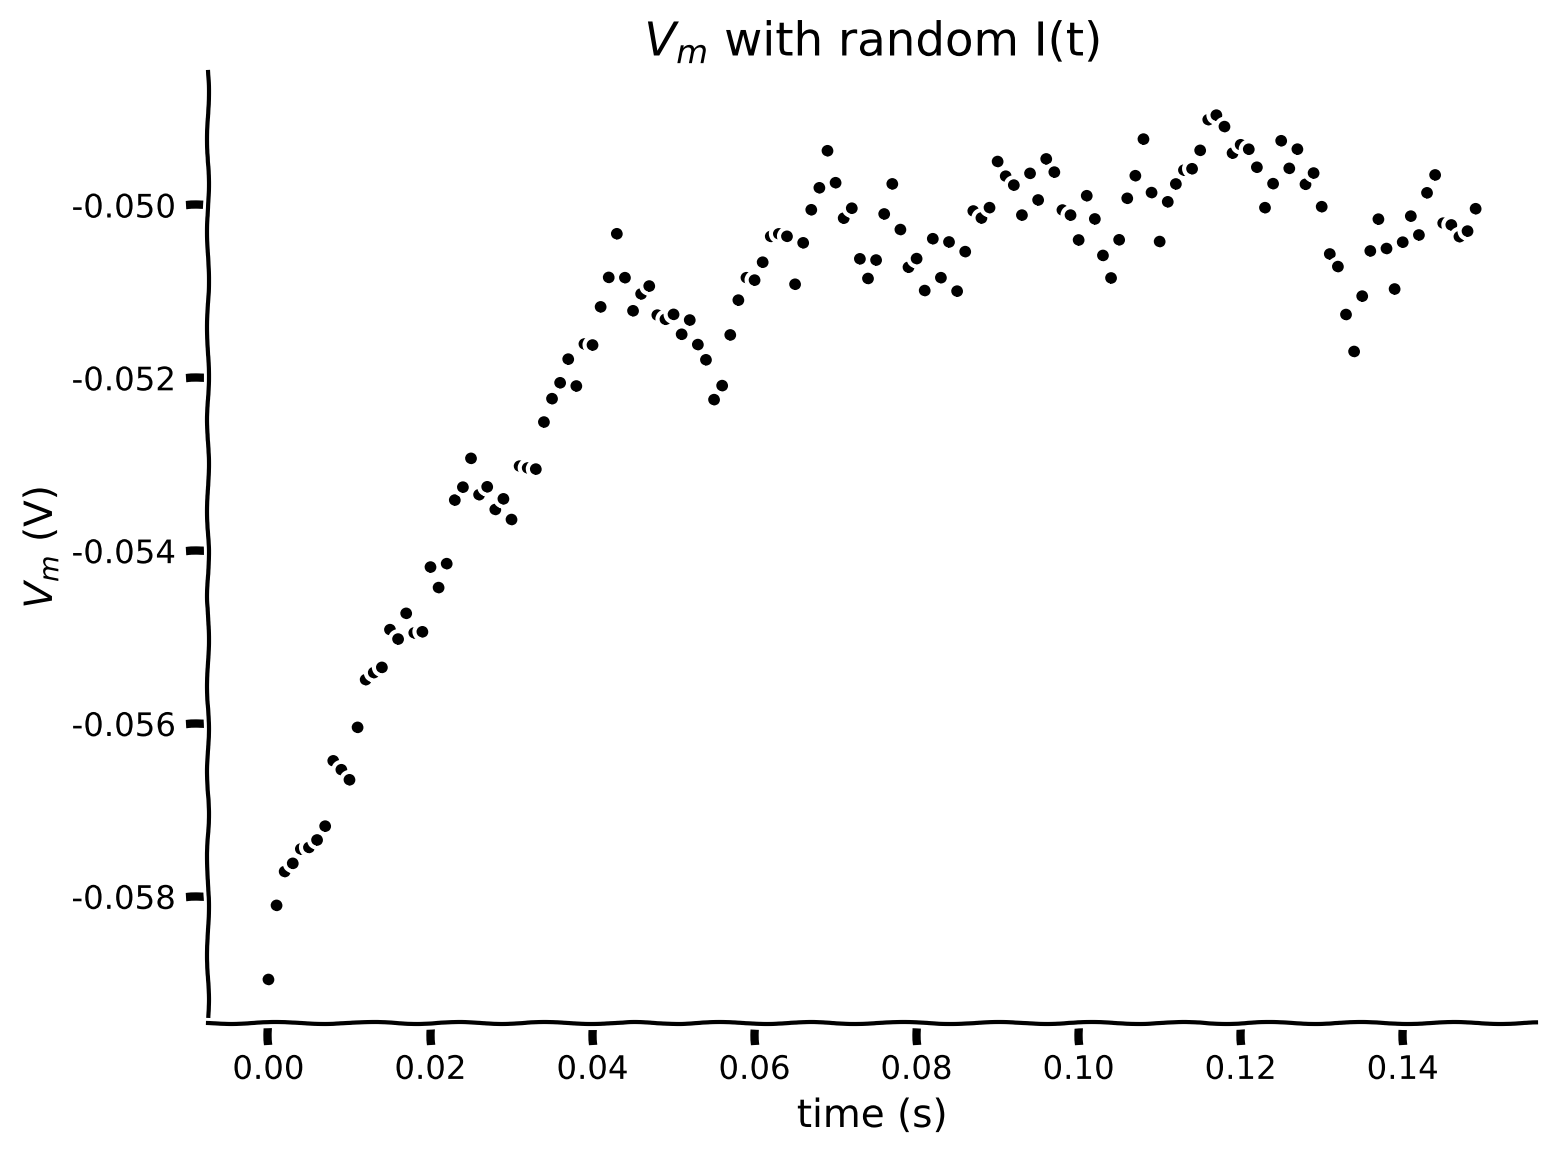

In [ ]:
# Set random number generator
np.random.seed(2020)

# Initialize step_end and v
step_end = int(t_max / dt)
v = el

with plt.xkcd():
  # Initialize the figure
  plt.figure()
  plt.title('$V_m$ with random I(t)')
  plt.xlabel('time (s)')
  plt.ylabel('$V_m$ (V)')

  # loop for step_end steps
  for step in range(step_end):

    # Compute value of t
    t = step * dt

    # Get random number in correct range of -1 to 1 (will need to adjust output of np.random.random)
    random_num = 2 * np.random.random() - 1

    # Compute value of i at this time step
    i =  i_mean * (1 + 0.1 * (t_max / dt)**(0.5) * random_num)

    # Compute v
    v = v + dt/tau * (el - v + r*i)

    # Plot v (using 'k.' to get even smaller markers)
    plt.plot(t, v, 'k.')


  # Display plot
  plt.show()

Random synaptic input $I(t)$ results in random time course for $V(t)$.

##  4.2: Running repeated simulation trials


- We'll collect the sample mean over $N=50$ realizations of $V(t)$  with random input.
- The sample mean, sample variance at times $\left\{t, s\right\}\in[0,t_{max}]$, and for $N$ repeated trials $V_n(t)$ are given by:

\begin{align}
\\
\left\langle V(t)\right\rangle &= \frac{1}{N}\sum_{n=1}^N V_n(t) & & \text{sample mean}\\
\left\langle (V(t)-\left\langle V(t)\right\rangle)^2\right\rangle &= \frac{1}{N-1} \sum_{n=1}^N \left(V_n(t)-\left\langle V(t)\right\rangle\right)^2 & & \text{sample variance} \\
\end{align}

---
**PYTHON BASICS: NUMPY**


- The time range, voltage values, and synaptic current are initialized or pre-computed as numpy arrays before numerical integration.

- We use `np.linspace` to initialize a numpy array `t_range` with `num=step_end=150` values from `0` to `t_max`


- We use `np.ones` to initialize a numpy array `v` with `step_end + 1` leak potential values `el`.

- You will pre-compute `step_end` synaptic current values in numpy array `i` with `np.random.random(step_end)` for `step_end` random numbers. Since `v[0]=el`, we should iterate for `step_end` steps but skip `step=0`.

**PYTHON BASICS: enumerate & indexing**

- Let's practice using `enumerate` to iterate over the indexes and values of the synaptic current array `i`. We want to get the step and the value of i at that step `i_step`


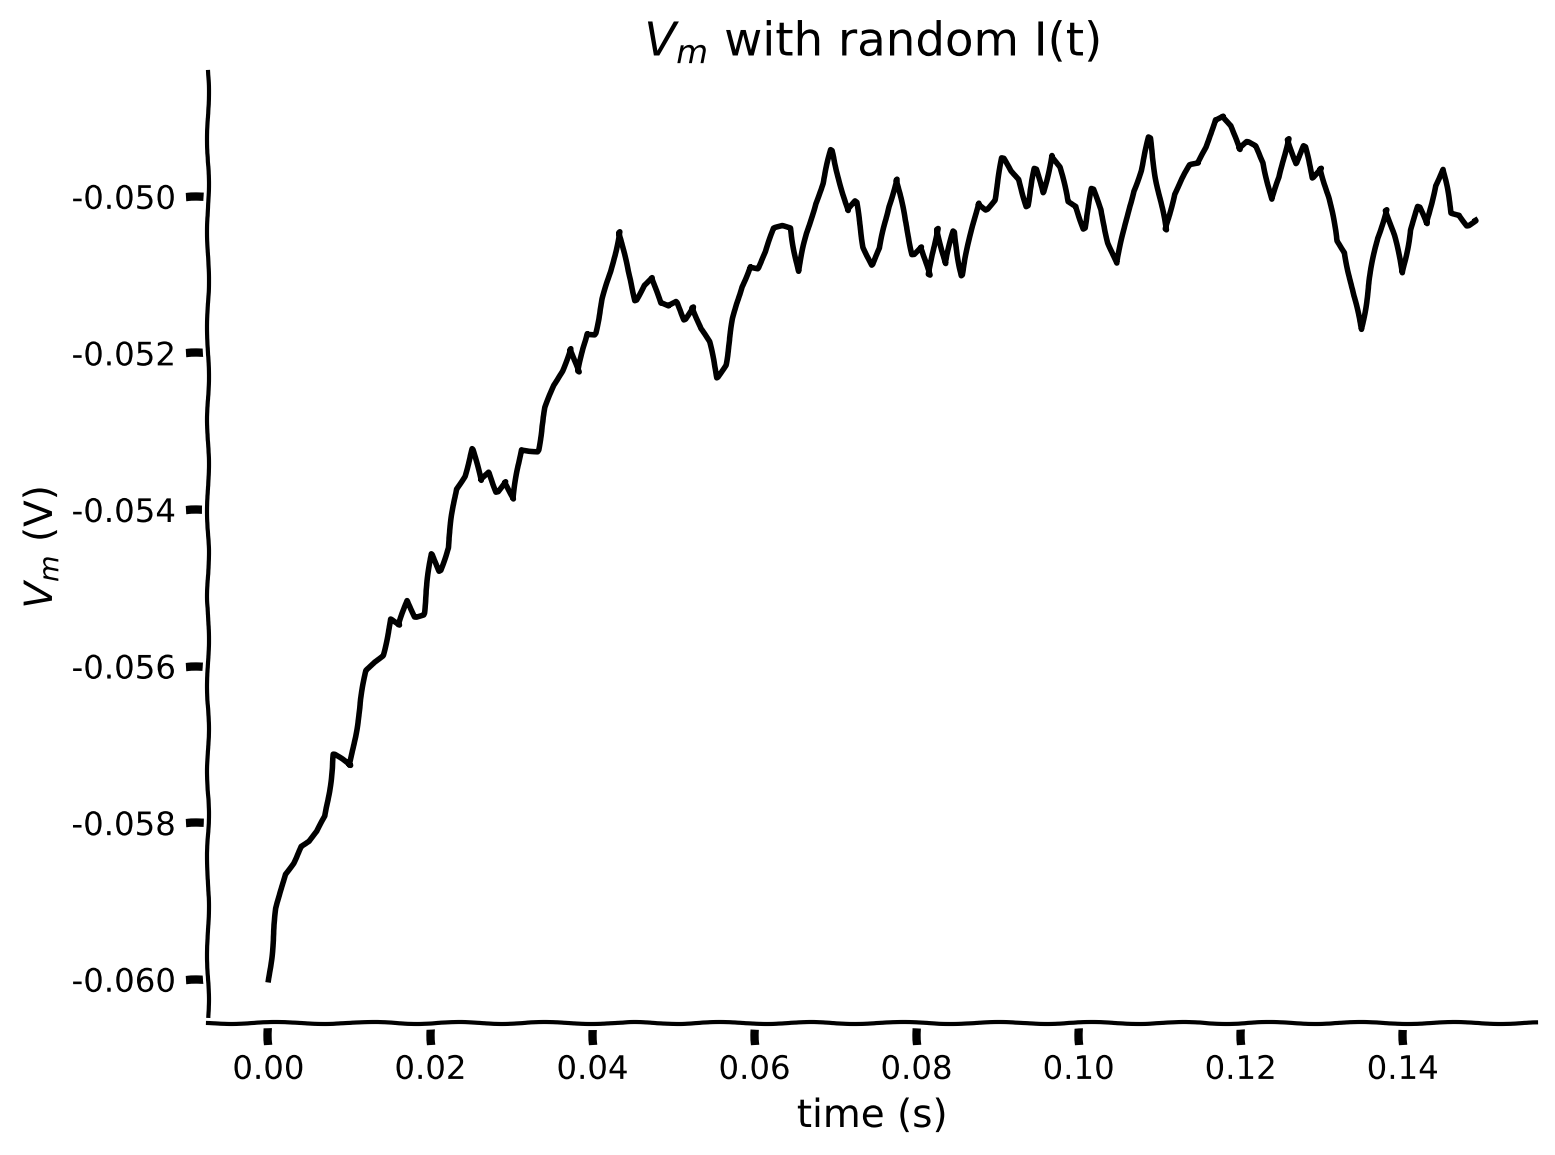

In [ ]:
# Set random number generator
np.random.seed(2020)

# Initialize step_end, t_range, v
step_end = int(t_max / dt) - 1
t_range = np.linspace(0, t_max, num=step_end, endpoint=False)
v = el * np.ones(step_end)

# Simulate current over time
i = i_mean * (1 + 0.1 * (t_max/dt) ** (0.5) * (2 * np.random.random(step_end) - 1))

# Loop for step_end values of i using enumerate
for step, i_step in enumerate(i):

  # Skip first iteration
  if step==0:
    continue

  # Compute v as function of i using i_step
  v[step] = v[step - 1] + (dt / tau) * (el - v[step - 1] + r * i_step)

# Plot figure
with plt.xkcd():
  plt.figure()
  plt.title('$V_m$ with random I(t)')
  plt.xlabel('time (s)')
  plt.ylabel('$V_m$ (V)')

  plt.plot(t_range, v, 'k')
  plt.show()

**PYTHON BASICS: 2D arrays**

- Plot multiple realizations ($N=50$) of $V(t)$ by storing the voltage of each neuron at time $t$ in a numpy array.

- We first initialize a numpy array `v_n` of shape `(n, step_end)` with membrane leak potential values `el`. We pre-compute synaptic current values in numpy array `i` of shape `(n, step_end)`. After computing v, we plot results with a single plot command, by providing `v_n.T` to the plot function. `v_n.T` is the transposed version of `v_n` (with rows and columns swapped).

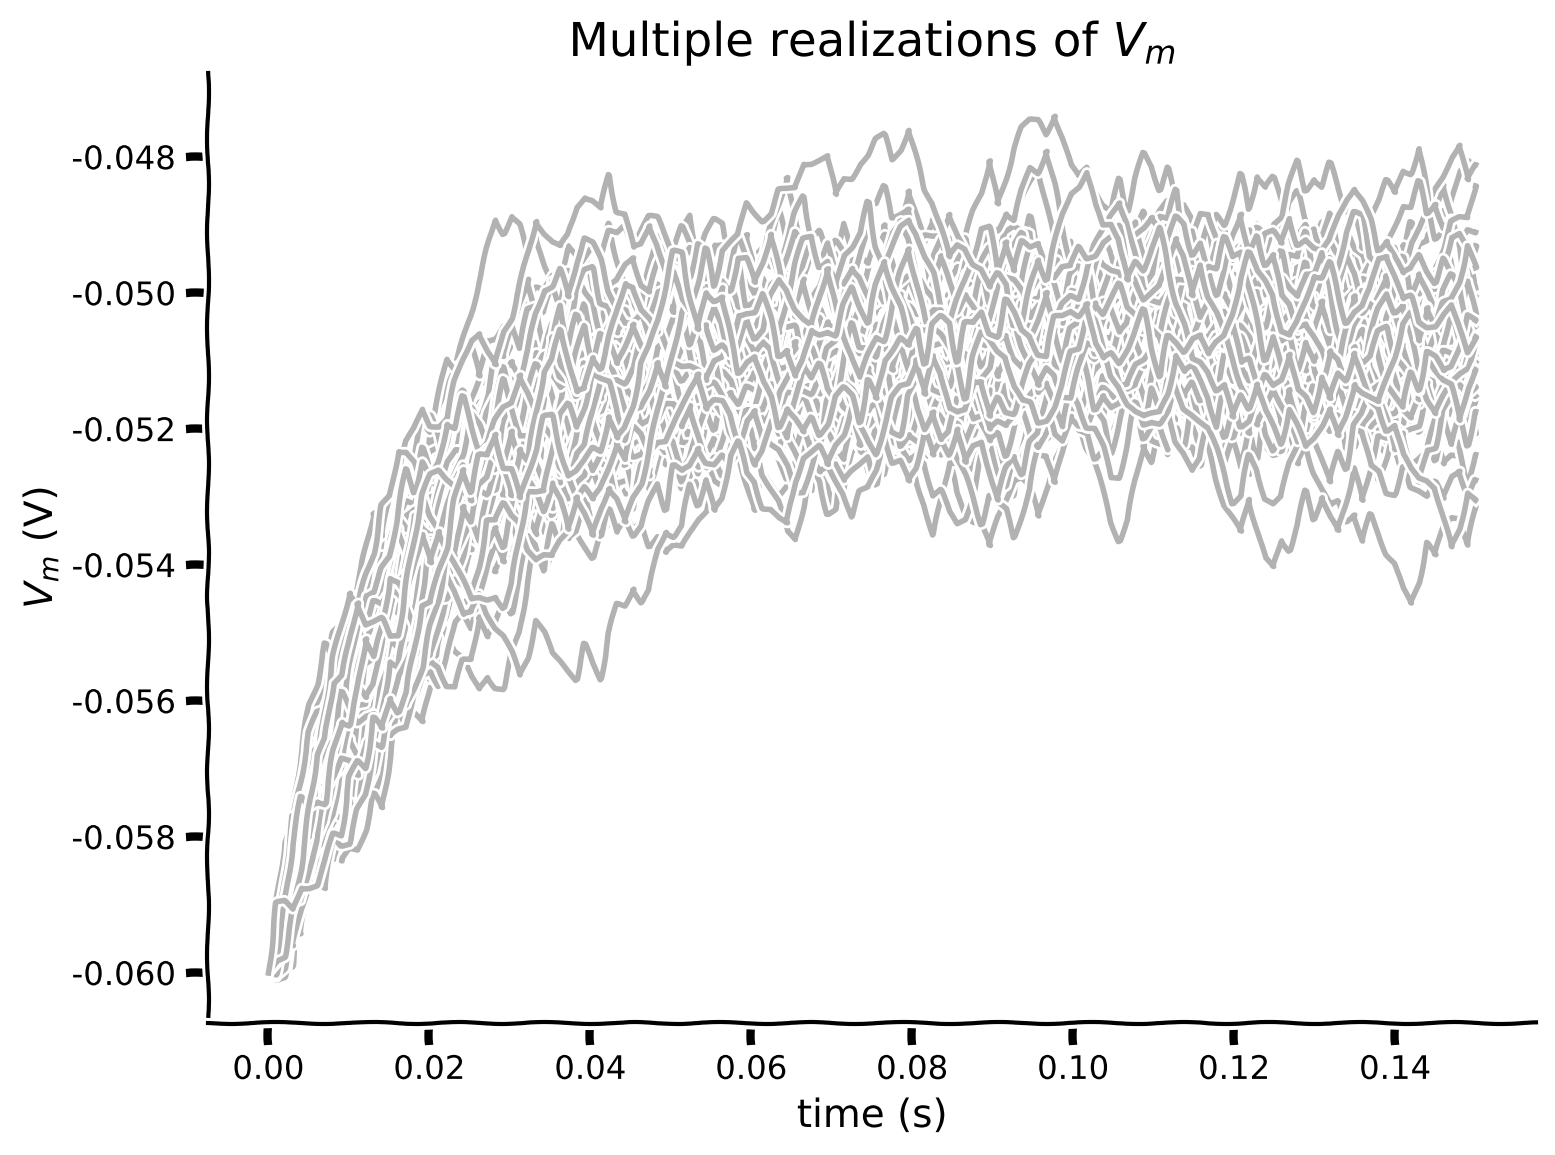

In [ ]:
# Set random number generator
np.random.seed(2020)

# Initialize step_end, n, t_range, v and i
step_end = int(t_max / dt)
n = 50
t_range = np.linspace(0, t_max, num=step_end)
v_n = el * np.ones([n, step_end])
i = i_mean * (1 + 0.1 * (t_max / dt)**(0.5) * (2 * np.random.random([n, step_end]) - 1))

# Loop for step_end - 1 steps
for step in range(1, step_end):

   # Compute v_n
   v_n[:, step] = v_n[:, step - 1] + (dt / tau) * (el - v_n[:, step - 1] + r * i[:, step])

# Plot figure
with plt.xkcd():

  plt.figure()
  plt.title('Multiple realizations of $V_m$')
  plt.xlabel('time (s)')
  plt.ylabel('$V_m$ (V)')

  plt.plot(t_range, v_n.T, 'k', alpha=0.3)
  plt.show()

## 4.3: Plotting sample mean and standard deviation

- Add the sample mean $\left\langle V(t)\right\rangle=\frac{1}{N}\sum_{n=1}^N V_n(t)$ to the plot.

- Add the sample standard deviation $\sigma(t)\equiv\sqrt{\text{Var}\left(t\right)}$ to the plot, with sample variance $\text{Var}(t) = \frac{1}{N-1} \sum_{n=1}^N \left(V_n(t)-\left\langle V(t)\right\rangle\right)^2$.

- `np.mean(v_n, axis=0)` computes mean over rows, i.e. mean for each neuron

- `np.mean(v_n, axis=1)` computes mean over columns (axis `1`), i.e. mean for each time step

- We will use label argument in plt.plot to specify labels in each trace.  We label only the last voltage trace to avoid labeling all N of them.

<>:35: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_411/1606919910.py:35: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(t_range, v_mean-v_std, 'C7', alpha=0.8, label='mean $\pm$ std')


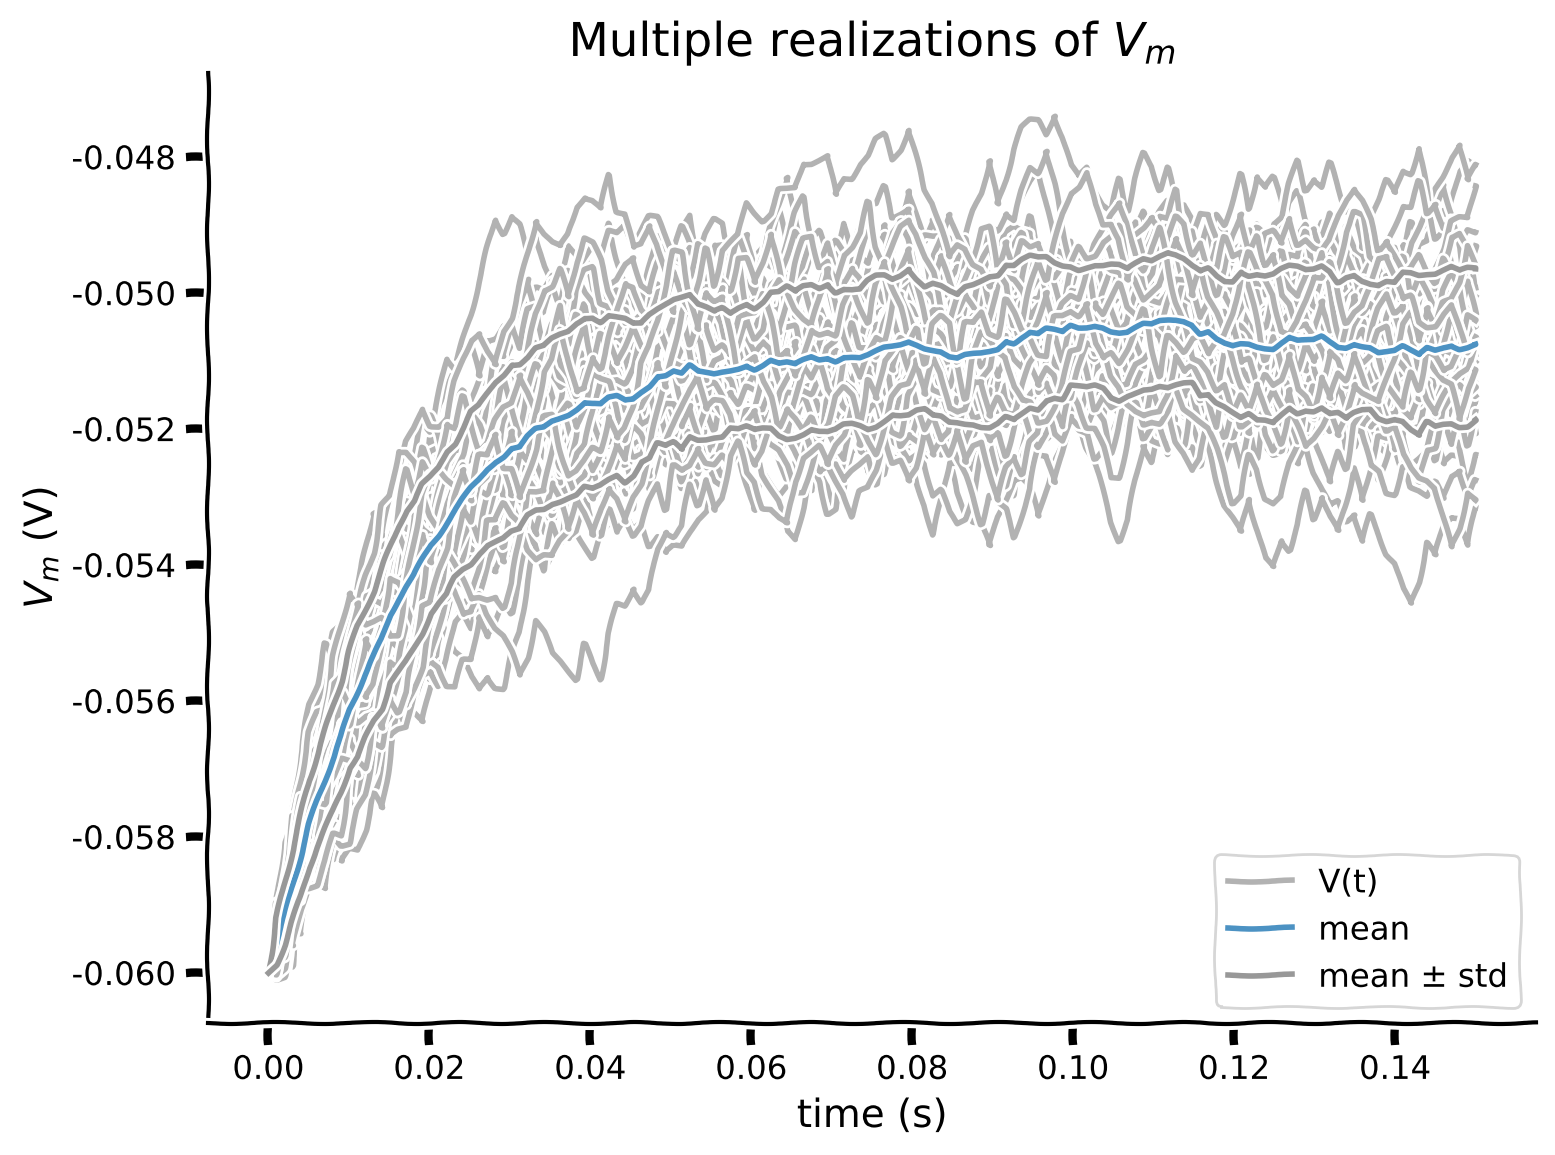

In [ ]:
# Set random number generator
np.random.seed(2020)

# Initialize step_end, n, t_range, v and i
step_end = int(t_max / dt)
n = 50
t_range = np.linspace(0, t_max, num=step_end)
v_n = el * np.ones([n, step_end])
i = i_mean * (1 + 0.1 * (t_max / dt)**(0.5) * (2 * np.random.random([n, step_end]) - 1))

# Loop for step_end - 1 steps
for step in range(1, step_end):

  # Compute v_n
  v_n[:, step] = v_n[:, step - 1] + (dt / tau) * (el - v_n[:, step - 1] + r * i[:, step])

# Compute sample mean (use np.mean)
v_mean = np.mean(v_n, axis=0)

# Compute sample standard deviation (use np.std)
v_std = np.std(v_n, axis=0)

# Plot figure
with plt.xkcd():
  plt.figure()
  plt.title('Multiple realizations of $V_m$')
  plt.xlabel('time (s)')
  plt.ylabel('$V_m$ (V)')

  plt.plot(t_range, v_n.T, 'k', alpha=0.3)

  plt.plot(t_range, v_n[-1], 'k', alpha=0.3, label='V(t)')
  plt.plot(t_range, v_mean, 'C0', alpha=0.8, label='mean')
  plt.plot(t_range, v_mean+v_std, 'C7', alpha=0.8)
  plt.plot(t_range, v_mean-v_std, 'C7', alpha=0.8, label='mean $\pm$ std')

  plt.legend()
  plt.show()

---
# 5: Adding spikes

## 5.1: Add a spike threshold $V_{th}$

- Here, we increase the **current's mean amplitude** to make the effect of **threshold crossing** and **refactory period** more apparent.

In [ ]:
# increased current amplitude
i_mean = 25e-11  # ampere

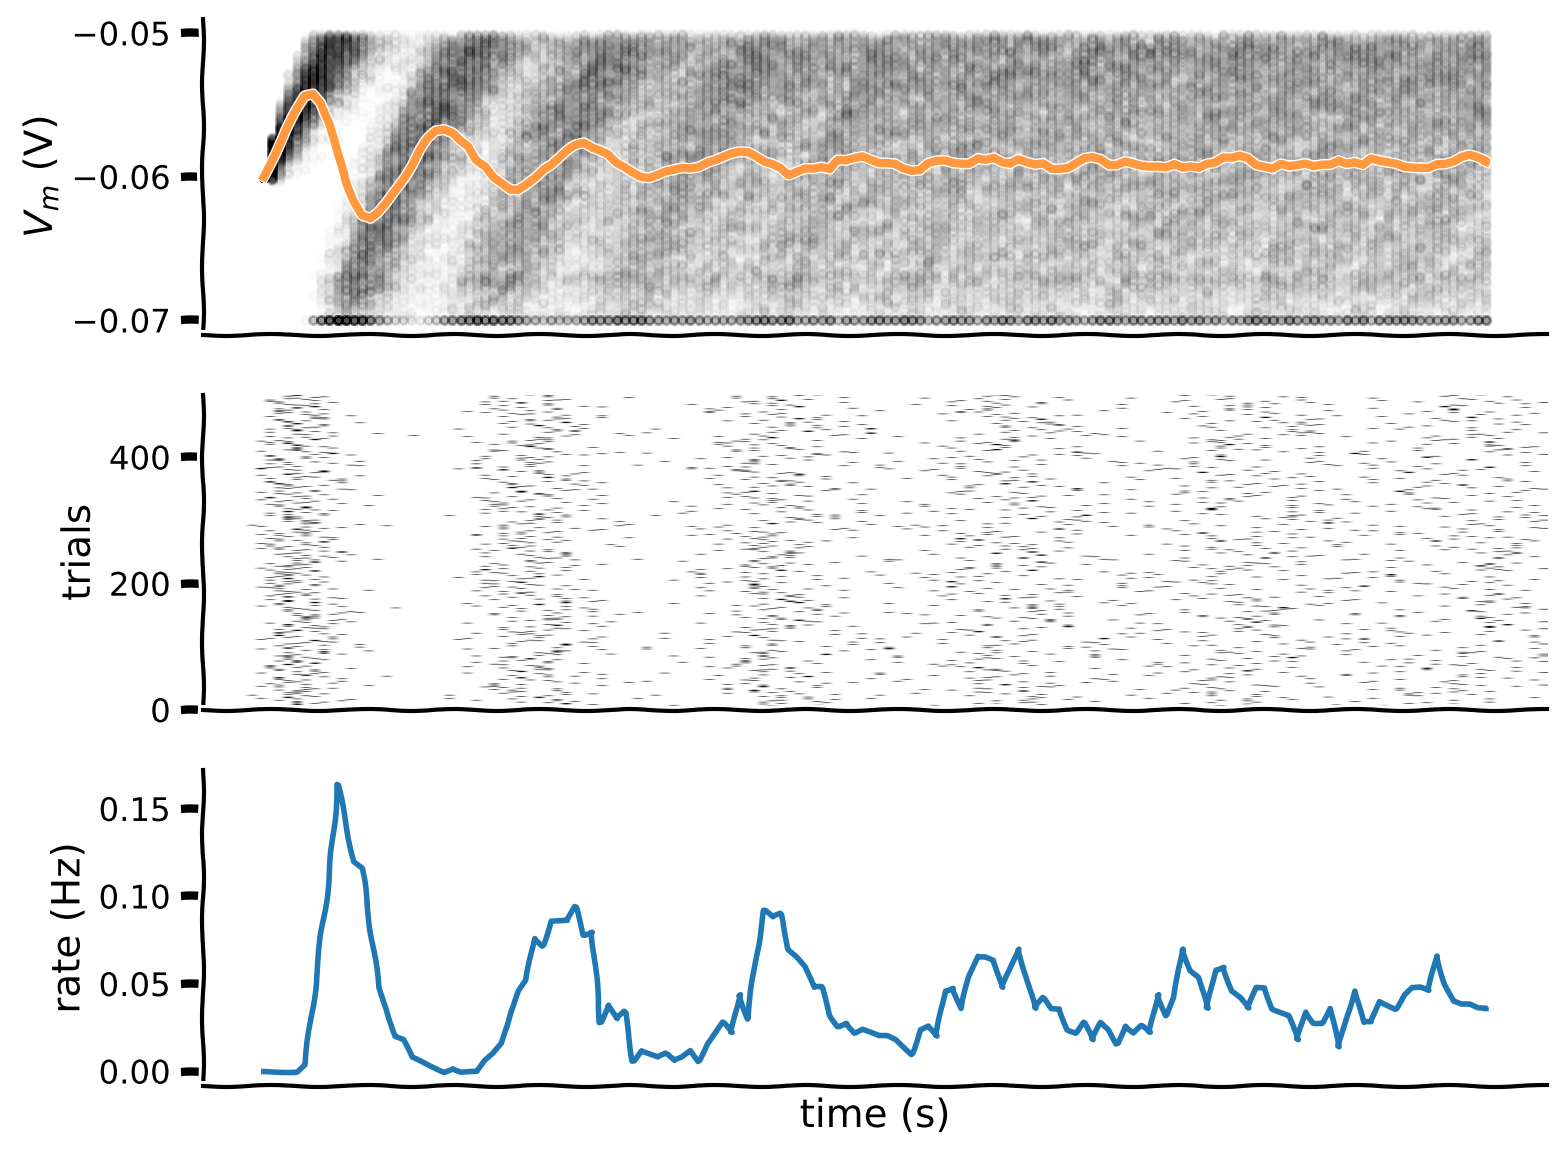

In [ ]:
# Set random number generator
np.random.seed(2020)

# Initialize step_end, n, t_range, v and i

# set the number of repeated trials
n = 500

# set parameters
step_end = int(t_max / dt)

# set the number of time bins within each trial
t_range = np.linspace(0, t_max, num=step_end)

# initialize the membrane potential V(t) to leak potential -0.060 millivolts
v_n = el * np.ones([n, step_end])

# simulate input current I(t) of shape (500 trials x 150 time bins)
i = i_mean * (1 + 0.1 * (t_max / dt)**(0.5) * (2 * np.random.random([n, step_end]) - 1))

# Initialize spikes and spikes_n
spikes = {j: [] for j in range(n)}
spikes_n = np.zeros([step_end])

# Loop over time steps
for step, t in enumerate(t_range):

  # Skip first iteration
  if step == 0:
    continue

  # Compute membrane potential v_n
  v_n[:, step] = v_n[:, step - 1] + (dt / tau) * (el - v_n[:, step - 1] + r*i[:, step])

  # Loop over simulated trials
  for j in range(n):

    # Check if voltage above threshold
    if v_n[j, step] >= vth:

      # Reset to reset voltage
      v_n[j, step] = vr

      # Add this spike time
      spikes[j] += [t]

      # Add spike count to this step
      spikes_n[step] += 1

# Collect mean Vm and mean spiking rate
v_mean = np.mean(v_n, axis=0)
spikes_mean =  spikes_n / n

with plt.xkcd():

  # Initialize the figure
  plt.figure()

  # Plot simulations and sample mean
  ax1 = plt.subplot(3, 1, 1)
  for j in range(n):
    plt.scatter(t_range, v_n[j], color="k", marker=".", alpha=0.01)
  plt.plot(t_range, v_mean, 'C1', alpha=0.8, linewidth=3)
  plt.ylabel('$V_m$ (V)')
  plt.xticks([])

  # Plot spikes
  # for each neuron j: collect spike times and plot them at height j
  if raster is not None:

    plt.subplot(3, 1, 2)
    spikes_mean = np.mean(raster, axis=0)
    plt.imshow(raster, cmap='Greys', origin='lower', aspect='auto')

  else:

    plt.subplot(3, 1, 2)
    for j in range(n):
      times = np.array(spikes[j])
      plt.scatter(times, j * np.ones_like(times), color="C0", marker=".", alpha=0.2)

  plt.xticks([])
  plt.ylabel('trials')

  # Plot firing rate
  plt.subplot(3, 1, 3)
  plt.plot(t_range, spikes_mean)
  plt.xlabel('time (s)')
  plt.ylabel('rate (Hz)')
  plt.xticks([])
  plt.tight_layout()

## 5.2 Adding a refractory period $t_{ref}$.

**PYTHON BASICS: functions**

In [ ]:
def plot_all(t_range, v, raster=None, spikes=None, spikes_mean=None):
  """
  Plots Time evolution for
  (1) multiple realizations of membrane potential
  (2) spikes
  (3) mean spike rate (optional)

  Args:
    t_range (numpy array of floats)
        range of time steps for the plots of shape (time steps)

    v (numpy array of floats)
        membrane potential values of shape (neurons, time steps)

    raster (numpy array of floats)
        spike raster of shape (neurons, time steps)

    spikes (dictionary of lists)
        list with spike times indexed by neuron number

    spikes_mean (numpy array of floats)
        Mean spike rate for spikes as dictionary

  Returns:
    Nothing.
  """

  v_mean = np.mean(v, axis=0)
  fig_w, fig_h = plt.rcParams['figure.figsize']
  plt.figure(figsize=(fig_w, 1.5 * fig_h))

  ax1 = plt.subplot(3, 1, 1)
  for j in range(n):
    plt.scatter(t_range, v[j], color="k", marker=".", alpha=0.01)
  plt.plot(t_range, v_mean, 'C1', alpha=0.8, linewidth=3)
  plt.xticks([])
  plt.ylabel(r'$V_m$ (V)')

  if raster is not None:
    plt.subplot(3, 1, 2)
    spikes_mean = np.mean(raster, axis=0)
    plt.imshow(raster, cmap='Greys', origin='lower', aspect='auto')

  else:
    plt.subplot(3, 1, 2, sharex=ax1)
    for j in range(n):
      times = np.array(spikes[j])
      plt.scatter(times, j * np.ones_like(times), color="C0", marker=".", alpha=0.2)

  plt.xticks([])
  plt.ylabel('neuron')

  if spikes_mean is not None:
    plt.subplot(3, 1, 3, sharex=ax1)
    plt.plot(t_range, spikes_mean)
    plt.xlabel('time (s)')
    plt.ylabel('rate (Hz)')

  plt.tight_layout()
  plt.show()

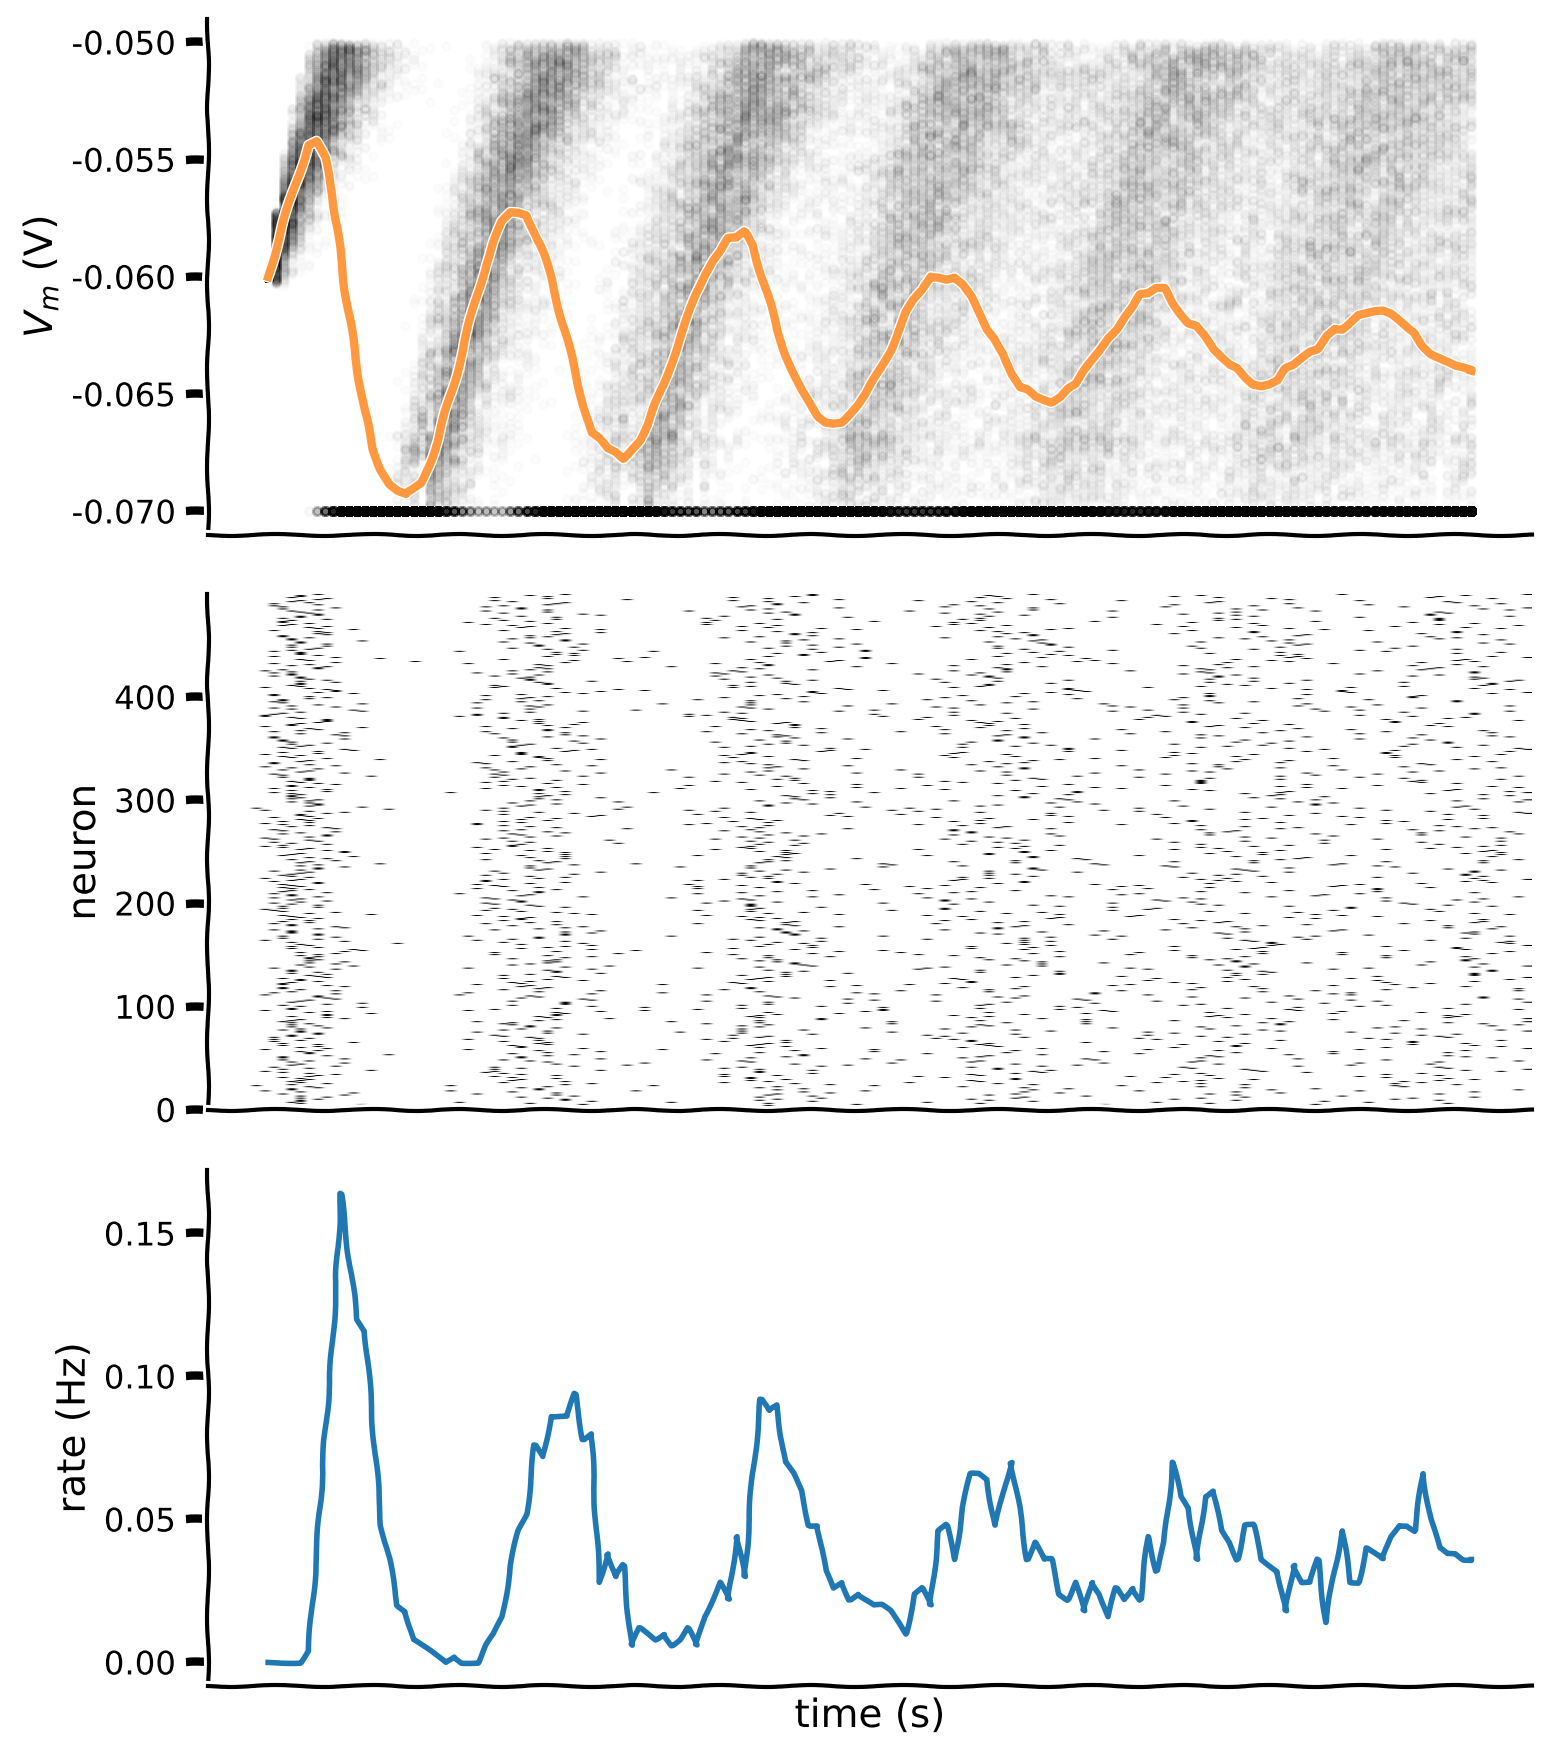

In [ ]:
# Set random number generator
np.random.seed(2020)

# Initialize step_end, t_range, n, v_n and i
t_range = np.arange(0, t_max, dt)
step_end = len(t_range)
n = 500
v_n = el * np.ones([n, step_end])
i = i_mean * (1 + 0.1 * (t_max / dt)**(0.5) * (2 * np.random.random([n, step_end]) - 1))

# Initialize binary numpy array for raster plot
raster = np.zeros([n,step_end])

# Initialize t_ref and last_spike
t_ref = 0.01
last_spike = -t_ref * np.ones([n])

# Loop over time steps
for step, t in enumerate(t_range):

  # Skip first iteration
  if step == 0:
    continue

  # Compute v_n
  v_n[:, step] = v_n[:, step - 1] + (dt / tau) * (el - v_n[:, step - 1] + r*i[:, step])

  # Initialize boolean numpy array `spiked` with v_n > v_thr
  spiked = (v_n[:,step] >= vth)

  # Set relevant values of v_n to v_reset using spiked
  v_n[spiked,step] = vr

  # Set relevant elements in raster to 1 using spiked
  raster[spiked,step] = 1.

  # Initialize boolean numpy array clamped using last_spike, t and t_ref
  clamped = (last_spike + t_ref > t)

  # Reset clamped neurons to vr using clamped
  v_n[clamped,step] = vr

  # Update numpy array last_spike with time t for spiking neurons
  last_spike[spiked] = t

# Plot multiple realizations of Vm, spikes and mean spike rate
with plt.xkcd():
  plot_all(t_range, v_n, raster)